In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [23]:
ferm = np.array([11.7, 14.4, 24.8, 21.2, 10.4, 14.3, 17.8, 25.4, 7.9, 27.6, 10.8, 23.8, 16.7, 11.8, 17.6, 15.6, 6.3, 14.5, 28.0, 20.4, 5.4, 21.6, 21.6, 15.9, 2.8, 17.5, 9.9, 17.2, 12.6, 13.3, 28.3, 28.4, 6.8, 8.9, 29.6, 17.6, 21.3, 18.5, 5.4, 17.5, 3.2, 2.0, 2.6, 16.1, 4.5, 3.0, 4.7, 16.7, 19.7, 8.0])
temp = np.array([32.6, 20.9, 24.9, 28.2, 28.0, 21.3, 21.1, 22.1, 27.1, 31.4, 20.8, 25.8, 21.5, 30.5, 24.3, 20.5, 28.8, 26.6, 28.6, 21.5, 22.2, 23.1, 31.5, 22.6, 29.0, 28.1, 28.7, 25.1, 30.1, 25.7, 22.1, 26.0, 29.0, 19.9, 29.7, 26.2, 32.5, 26.4, 32.1, 20.9, 20.1, 25.9, 18.1, 25.9, 19.7, 31.3, 30.2, 25.2, 20.1, 31.0])

y_train = np.array([0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0])
ferm.shape, temp.shape

((50,), (50,))

In [24]:
y_train.mean(), 1-y_train.mean()

(np.float64(0.5), np.float64(0.5))

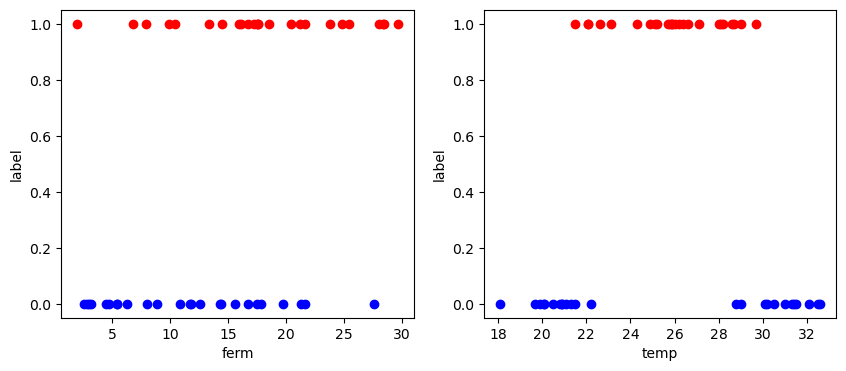

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].scatter(ferm[y_train==1], y_train[y_train== 1], marker="o", color="r")
ax[0].scatter(ferm[y_train == 0], y_train[y_train == 0], marker = "o", color = "b")
ax[0].set_xlabel("ferm")
ax[0].set_ylabel("label")


ax[1].scatter(temp[y_train==1], y_train[y_train== 1], marker="o", color="r")
ax[1].scatter(temp[y_train == 0], y_train[y_train == 0], marker = "o", color = "b")
ax[1].set_xlabel("temp")
ax[1].set_ylabel("label")

plt.show()

In [26]:
x_train = np.array([ferm, temp, temp**2])
x_train = x_train.T
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_train)
np.ptp(x_scaled, axis = 0)

array([3.57271523, 3.55967897, 3.50580512])

In [35]:
lgdr = LogisticRegression(C=100)
lgdr.fit(x_scaled, y_train)

LogisticRegression(C=100)

In [36]:
prediction = lgdr.predict(x_scaled)
prediction

array([0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0])

In [37]:
lgdr.score(x_scaled, y_train)

0.94

In [41]:
final_prediction = lgdr.predict(scaler.transform(np.array([[18.0, 27.0, 27.0**2]])))
print(final_prediction[0])

1


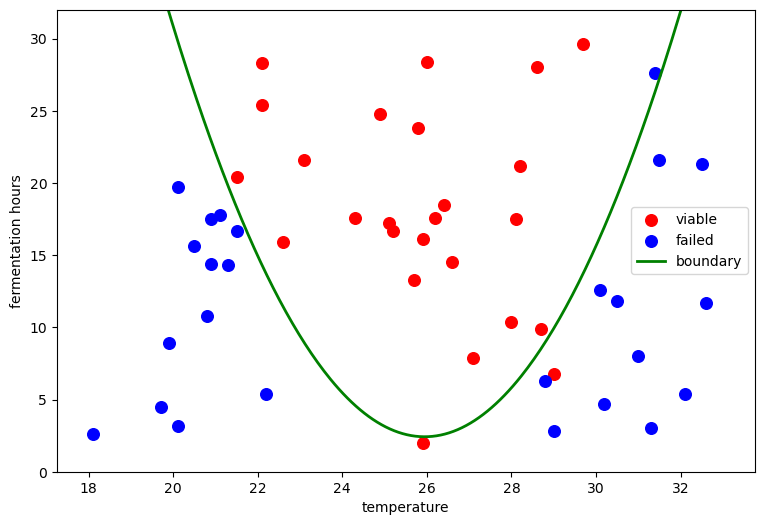

In [42]:
w = lgdr.coef_[0]
b = lgdr.intercept_[0]
mu, sd = scaler.mean_, scaler.scale_

plt.figure(figsize=(9, 6))
plt.scatter(temp[y_train == 1], ferm[y_train == 1], color="r", s=70, label="viable")
plt.scatter(temp[y_train == 0], ferm[y_train == 0], color="b", s=70, label="failed")

# boundary: solve w0*ferm + w1*temp + w2*temp^2 + b = 0 for ferm
t_grid = np.linspace(18, 33, 300)
t_sc = (t_grid - mu[1]) / sd[1]
t2_sc = (t_grid**2 - mu[2]) / sd[2]
f_sc = -(w[1]*t_sc + w[2]*t2_sc + b) / w[0]
f_raw = f_sc * sd[0] + mu[0]

plt.plot(t_grid, f_raw, color="g", lw=2, label="boundary")
plt.ylim(0, 32)
plt.xlabel("temperature")
plt.ylabel("fermentation hours")
plt.legend()
plt.show()